In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_df = pd.read_csv('/content/ecom_data_transformed.csv')
data_df

,gender,order_fashion,order_grocery,order_laptop,order_phone,order_mobile_phone,order_others,divorced,married,single,...,hour_spend,device_registered,satisfaction_score,number_address,complain,order_lastyear,coupon_used,order_count,days_lastorder,cashback_amount
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.0,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.0,160.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,3.0,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.0,121.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,2.0,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.0,120.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2.0,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.0,134.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,3.0,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3.0,2.0,1.0,6.0,0.0,18.0,1.0,2.0,4.0,151.0
5626,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3.0,5.0,5.0,6.0,0.0,16.0,1.0,2.0,3.0,225.0
5627,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3.0,2.0,4.0,3.0,1.0,21.0,1.0,2.0,4.0,186.0
5628,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,4.0,5.0,4.0,4.0,0.0,15.0,2.0,2.0,9.0,179.0


In [3]:
data_df.dtypes.value_counts()

,count
float64,34


In [4]:
data_df.isnull().sum().sum()

np.int64(0)

# CORRELACIONES

In [5]:
corr_matrix = data_df.corr()
corr_churn = corr_matrix['churn']
corr_churn.sort_values(ascending=False)

,churn
churn,1.000000
complain,0.250188
single,0.180847
order_mobile_phone,0.154387
order_phone,0.113364
device_registered,0.107939
satisfaction_score,0.105481
city_tier,0.084703
payment_cod,0.083933
login_phone,0.078916


<Axes: >

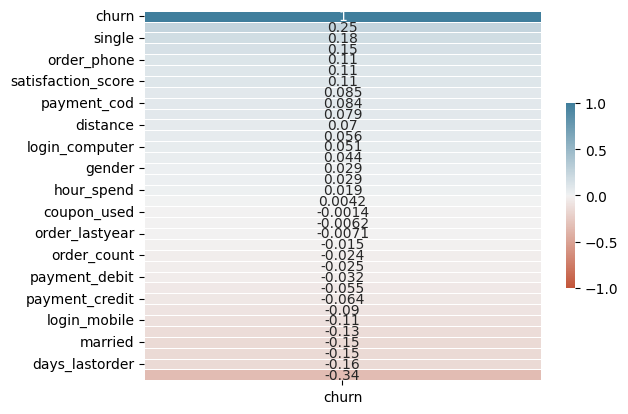

In [6]:
sns.heatmap(
    data=corr_churn.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [7]:
corr_filtered = corr_churn[(corr_churn >= 0.1) & (corr_churn < 1)]
corr_filtered
cols = corr_filtered.index.tolist()
cols

['order_phone',
 'order_mobile_phone',
 'single',
 'device_registered',
 'satisfaction_score',
 'complain']

In [8]:
X = data_df[cols].values
y = data_df['churn'].values


# ENTRENAMIENTO CON ARBOL DE DECISIÓN

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=00000)

In [10]:
from sklearn.model_selection import GridSearchCV
# definirmos varios parametros
param_grid = {
    'max_depth': [3,4,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'criterion':['gini','entropy']
}
clf = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(clf,param_grid,cv=5,scoring='accuracy',n_jobs=1)
grid_search.fit(X_train,y_train)

print(f"Mejores parametros: {grid_search.best_params_}")

Mejores parametros: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [11]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy best model : {accuracy}')

Accuracy best model : 0.8374777975133215


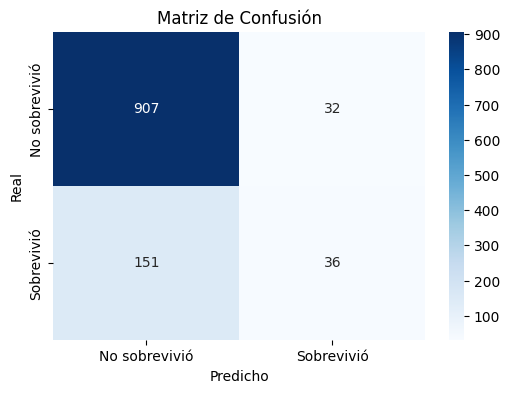

In [12]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()